In [2]:
import numpy as np
import matplotlib.pyplot as plt

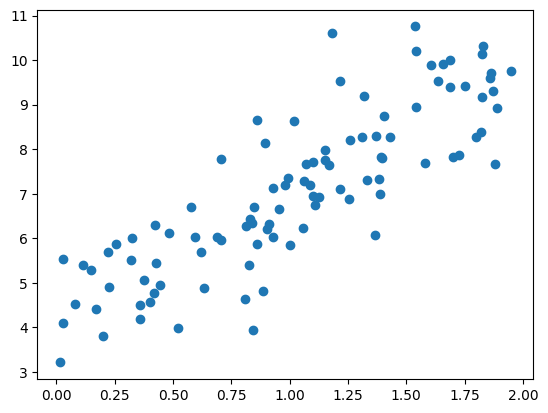

In [3]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)
plt.scatter(X,y)
plt.show()

In [4]:
X_b = np.c_[np.ones((100,1)),X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [5]:
theta_best

array([[4.15171751],
       [2.85405673]])

In [6]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.15171751],
       [9.85983097]])

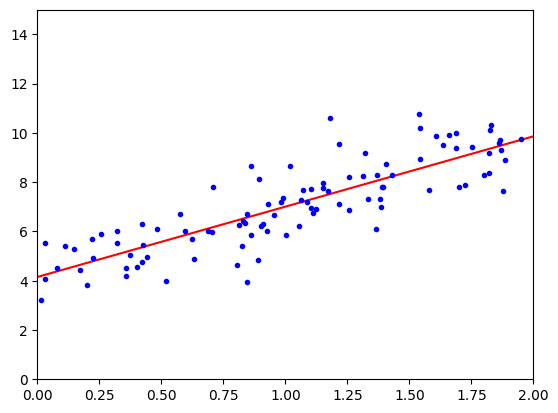

In [7]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_


(array([4.15171751]), array([[2.85405673]]))

In [9]:
lin_reg.predict(X_new)

array([[4.15171751],
       [9.85983097]])

In [10]:
theta_best_svd, residuals, ranks, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.15171751],
       [2.85405673]])

<h3>Batch Gradient Descent
</h3>

In [12]:
alpha = 0.1
n_iterations = 1000 
m = 1000 # no of training examples 

theta = np.random.randn(2,1) 

for iteration in range(n_iterations):
    gradient = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - alpha * gradient#to get the new theta value

In [13]:
theta
#to find a good learning rate use grid search
#set no of iteration large and interrupt when gradient become tiny 
#when gradient reaches at minimum at 

array([[4.13302974],
       [2.86994964]])

<h3>stochastic Gradient Descent </h3>

- major problem is Batch Gradient descent uses whole trainig set at every step
- has good accuracy but it is high memory based and intensiv

<h4>how stochastic gradient descent work</h4>

- it simply pick random instance on training set and calculate gradient at that point
- it run faster on single instances
- on that case it can work on huge datasets
- here gradeints are random and cost function dereasing  average
- once it will reach global minima it will not settle and keep bouncing here and there
- it escape local minima early but never settle on global minina for that `decrese learning rate over time `
- one more thing is we can suffle the input featuers

In [17]:
n_epochs = 50

t0, t1 = 5, 50 

def learning_rate(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index : random_index+1]
        gradient = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_rate(epoch * m +i)
        theta = theta - eta * gradient

In [18]:
theta

array([[4.32030157],
       [2.72389415]])

In [19]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000, tol = 1e-3, penalty = None, eta0 = 0.1)
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [20]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.16550283]), array([2.88324056]))

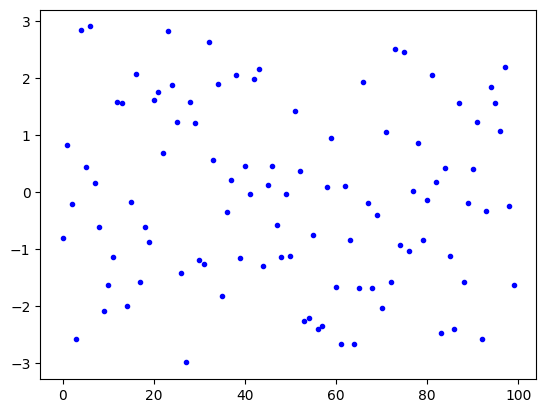

In [21]:
m = 100
X = 6 * np.random.rand(m,1) - 3

plt.plot(X,'b.')

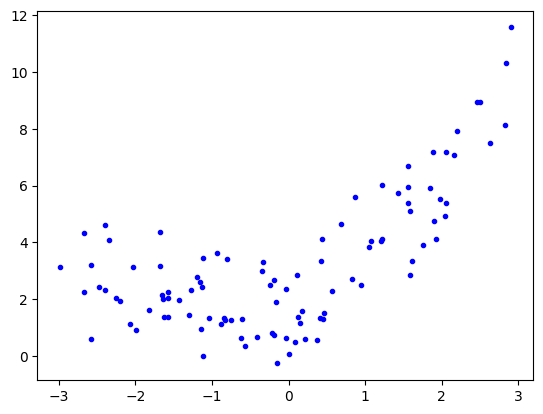

In [22]:
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1)
plt.plot(X, y, 'b.')

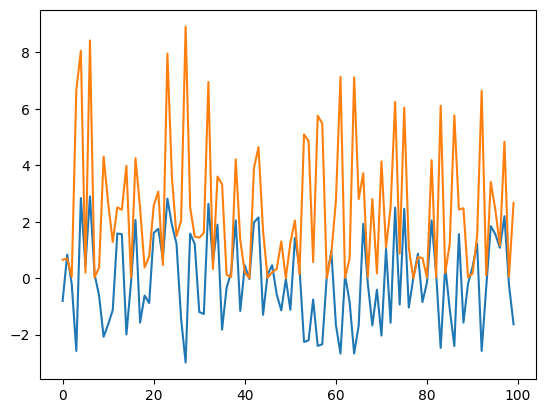

In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
plt.plot(X_poly)

In [24]:
#X_poly contain origianl features of X + squared one 
#so now fit linear features of X
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_
#bias, theta1(X), theta2(X^2)

(array([1.89153299]), array([[1.01181828, 0.58365251]]))

In [66]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)
    train_errors, val_errors = [], [] #creating list to store error
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

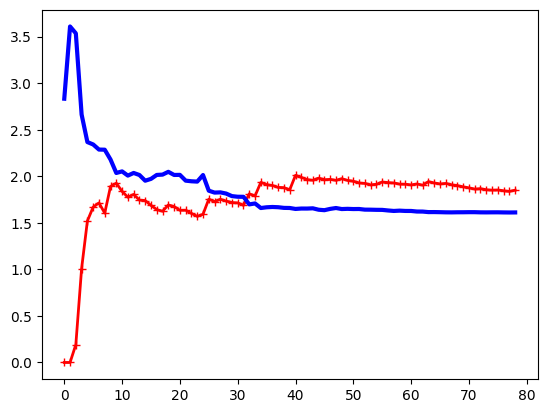

In [68]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)